In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/heart_disease_dataset.csv')

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [5]:
df['Alcohol Intake'].unique()

array(['Heavy', nan, 'Moderate'], dtype=object)

In [6]:
df['Alcohol Intake'] = df['Alcohol Intake'].fillna('No')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           1000 non-null   object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

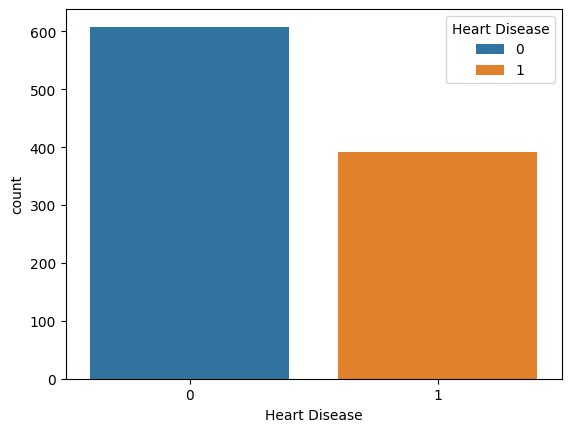

In [8]:
sns.countplot(x='Heart Disease', data=df, hue='Heart Disease');

In [9]:
df['Heart Disease'].value_counts()

Heart Disease
0    608
1    392
Name: count, dtype: int64

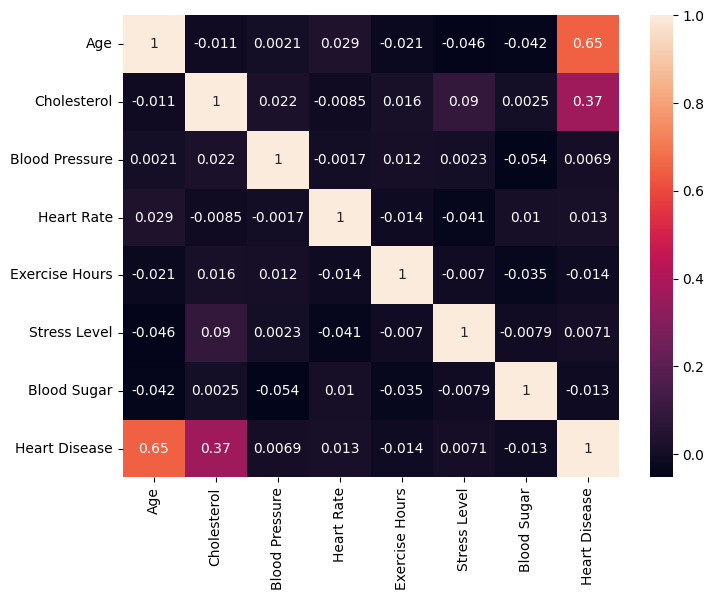

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True);

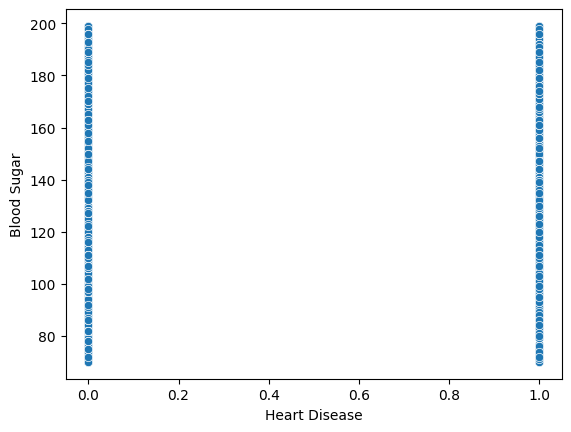

In [11]:
sns.scatterplot(x='Heart Disease', y='Blood Sugar', data=df);

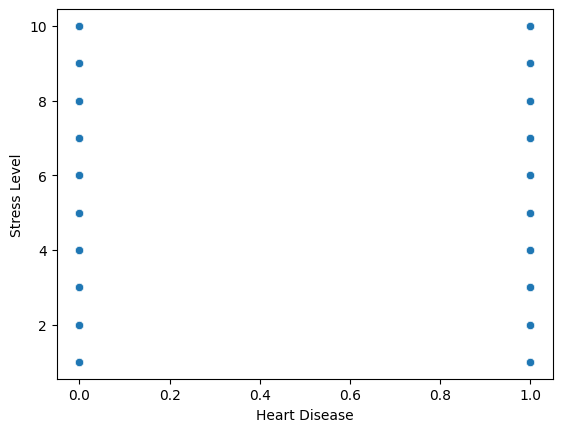

In [12]:
sns.scatterplot(x='Heart Disease', y='Stress Level', data=df);

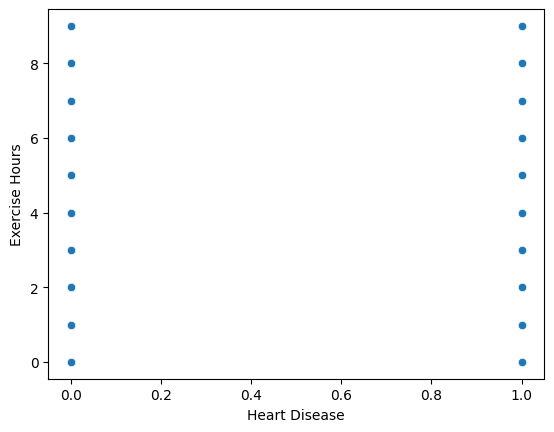

In [13]:
sns.scatterplot(x='Heart Disease', y='Exercise Hours', data=df);

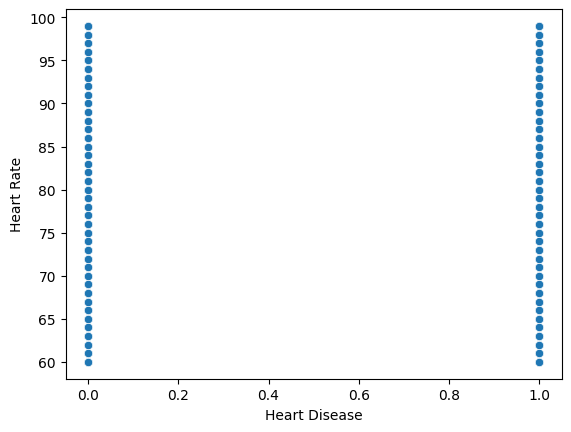

In [14]:
sns.scatterplot(x='Heart Disease', y='Heart Rate', data=df);

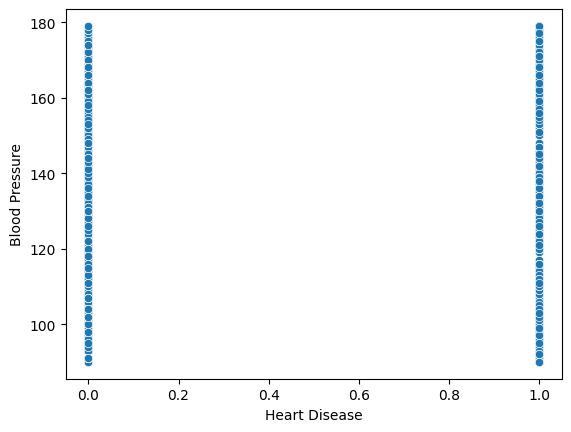

In [15]:
sns.scatterplot(x='Heart Disease', y='Blood Pressure', data=df);

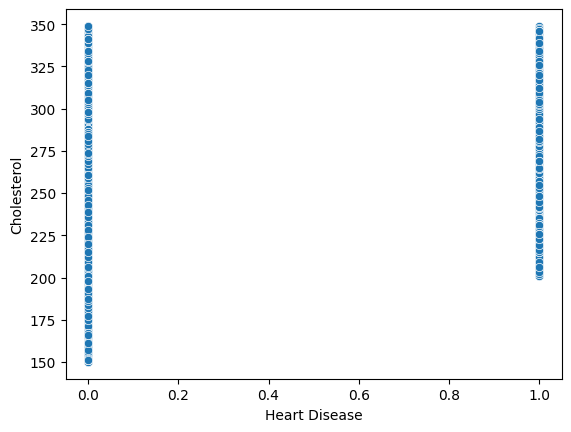

In [16]:
sns.scatterplot(x='Heart Disease', y='Cholesterol', data=df);

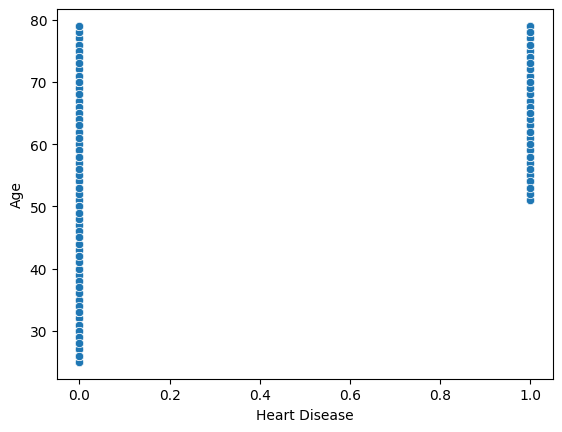

In [17]:
sns.scatterplot(x='Heart Disease', y='Age', data=df);

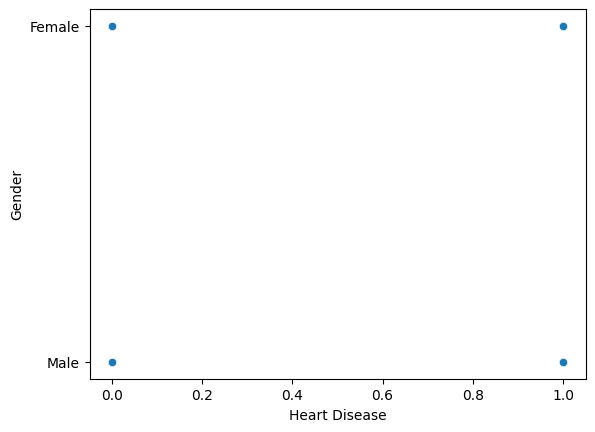

In [18]:
sns.scatterplot(x='Heart Disease', y='Gender', data=df);

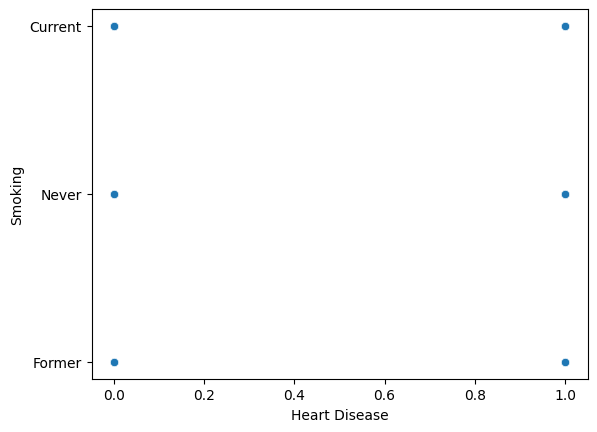

In [19]:
sns.scatterplot(x='Heart Disease', y='Smoking', data=df);

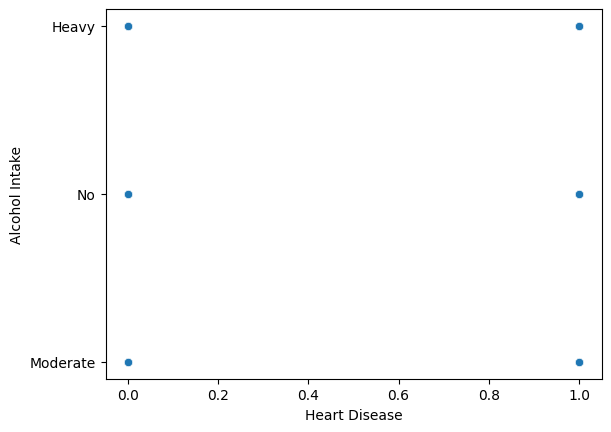

In [20]:
sns.scatterplot(x='Heart Disease', y='Alcohol Intake', data=df);

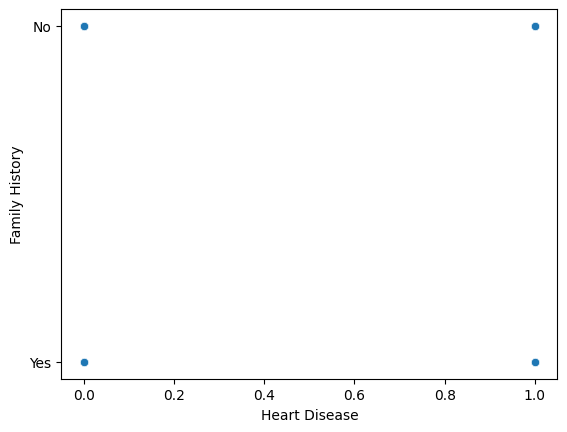

In [21]:
sns.scatterplot(x='Heart Disease', y='Family History', data=df);

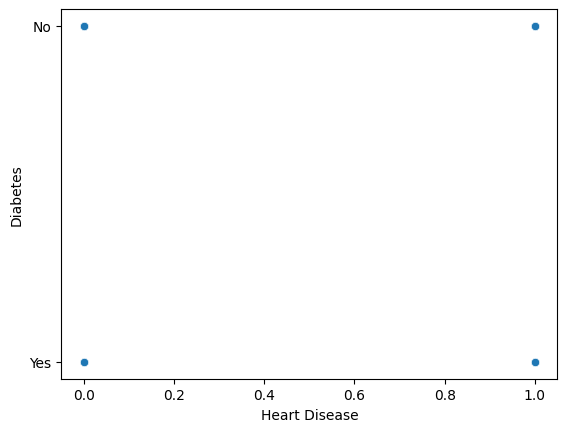

In [22]:
sns.scatterplot(x='Heart Disease', y='Diabetes', data=df);

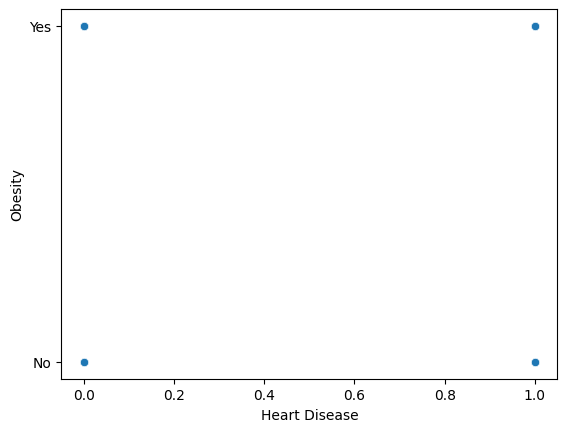

In [23]:
sns.scatterplot(x='Heart Disease', y='Obesity', data=df);

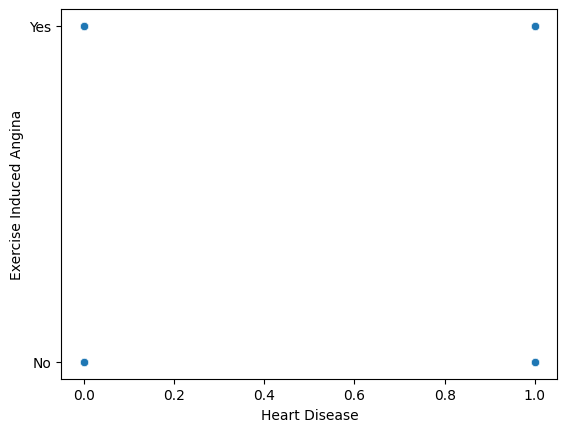

In [24]:
sns.scatterplot(x='Heart Disease', y='Exercise Induced Angina', data=df);

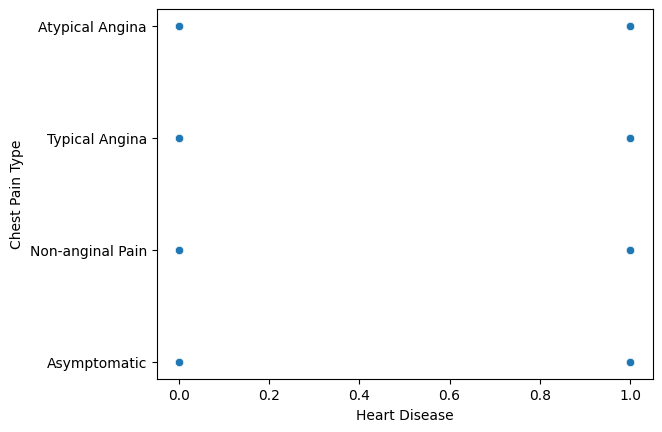

In [25]:
sns.scatterplot(x='Heart Disease', y='Chest Pain Type', data=df);

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.impute import KNNImputer

In [27]:
X = df.drop('Heart Disease', axis=1)

In [28]:
y = df['Heart Disease']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [30]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [31]:
num_features

['Age',
 'Cholesterol',
 'Blood Pressure',
 'Heart Rate',
 'Exercise Hours',
 'Stress Level',
 'Blood Sugar']

In [32]:
cat_features

['Gender',
 'Smoking',
 'Alcohol Intake',
 'Family History',
 'Diabetes',
 'Obesity',
 'Exercise Induced Angina',
 'Chest Pain Type']

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

In [34]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LogisticRegressionCV(cv=10,
                                   penalty='l1',
                                   solver='liblinear',
                                   Cs=10,
                                   max_iter=100_000,
                                   n_jobs=-1,
                                  random_state=104))
])

In [35]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [36]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [37]:
y_pred = pipe.predict(X_test)

In [38]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_model.C_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение C: [0.35938137]
Лучшее значение l1_ratio: [None]


In [39]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [40]:
accuracy

0.95

In [41]:
precision

0.9743589743589743

In [42]:
recall

0.9047619047619048

In [43]:
y_prob_test = pipe.predict_proba(X_test)[:, 1]
y_prob_train = pipe.predict_proba(X_train)[:, 1]

In [44]:
roc_auc_test = roc_auc_score(y_test, y_prob_test)
roc_auc_train = roc_auc_score(y_train, y_prob_train)

In [45]:
roc_auc_test

0.9975369458128079

In [46]:
roc_auc_train

0.9993558441558441

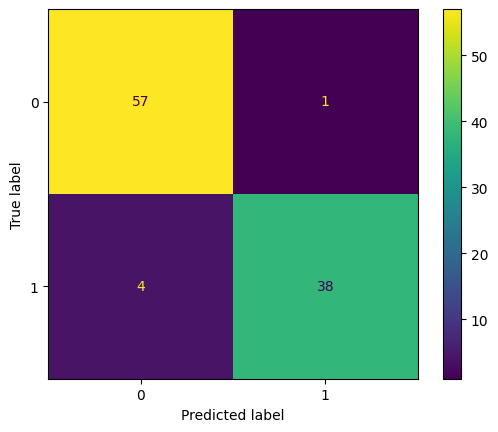

In [47]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test);

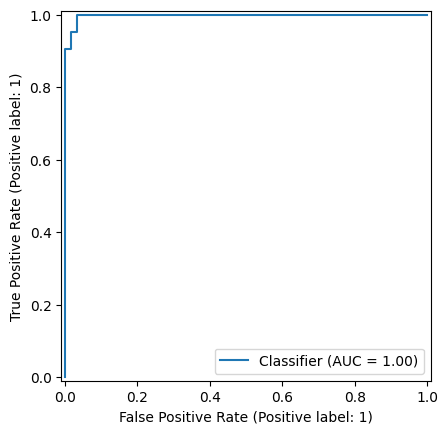

In [48]:
RocCurveDisplay.from_predictions(y_test, y_prob_test);

In [49]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [50]:
y_full_pred_proba = pipe.predict_proba(X)[:, 1]

In [51]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_final_model.C_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение C: [0.35938137]
Лучшее значение l1_ratio: [None]


In [52]:
roc_auc_full = roc_auc_score(y, y_full_pred_proba)

In [53]:
roc_auc_full

0.9994881176154673

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           1000 non-null   object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [55]:
df['Smoking'].unique()

array(['Current', 'Never', 'Former'], dtype=object)

In [56]:
df['Alcohol Intake'].unique()

array(['Heavy', 'No', 'Moderate'], dtype=object)

In [57]:
df['Family History'].unique()

array(['No', 'Yes'], dtype=object)

In [58]:
df['Diabetes'].unique()

array(['No', 'Yes'], dtype=object)

In [59]:
df['Obesity'].unique()

array(['Yes', 'No'], dtype=object)

In [60]:
df['Exercise Induced Angina'].unique()

array(['Yes', 'No'], dtype=object)

In [61]:
df['Chest Pain Type'].unique()

array(['Atypical Angina', 'Typical Angina', 'Non-anginal Pain',
       'Asymptomatic'], dtype=object)

In [62]:
test_df = pd.DataFrame([
    {
        'Age': 25, 
        'Gender': 'Male', 
        'Cholesterol': 150, 
        'Blood Pressure': 110, 
        'Heart Rate': 65, 
        'Smoking': 'Never', 
        'Alcohol Intake': 'No', 
        'Exercise Hours': 8, 
        'Family History': 'No', 'Diabetes': 'No', 
        'Obesity': 'No', 
        'Stress Level': 2, 
        'Blood Sugar': 80, 
        'Exercise Induced Angina': 'No', 
        'Chest Pain Type': 'Asymptomatic'
    },
    {
        'Age': 68, 
        'Gender': 'Male', 
        'Cholesterol': 290, 
        'Blood Pressure': 160, 
        'Heart Rate': 95, 
        'Smoking': 'Current', 
        'Alcohol Intake': 'Heavy', 
        'Exercise Hours': 0, 
        'Family History': 'Yes', 
        'Diabetes': 'Yes', 
        'Obesity': 'Yes', 
        'Stress Level': 9, 
        'Blood Sugar': 140, 
        'Exercise Induced Angina': 'Yes', 
        'Chest Pain Type': 'Typical Angina'
    }
])

In [63]:
test_df

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type
0,25,Male,150,110,65,Never,No,8,No,No,No,2,80,No,Asymptomatic
1,68,Male,290,160,95,Current,Heavy,0,Yes,Yes,Yes,9,140,Yes,Typical Angina


In [64]:
probabilities = pipe.predict_proba(test_df)[:, 1]
ill = pipe.predict(test_df)

In [65]:
print(f"--- Вероятность болезни у молодого спортсмена: {probabilities[0]:.2%}")
print(f"--- Вероятность болезни у пациента из группы риска: {probabilities[1]:.2%}")

for el, i in enumerate(ill):
    if el == 1:
        print(f"--- Пациент номер {i+1} имеет сердечную болезнь!")
    elif el == 0:
        print(f"--- Пациент номер {i+1} здоров!")

--- Вероятность болезни у молодого спортсмена: 0.02%
--- Вероятность болезни у пациента из группы риска: 100.00%
--- Пациент номер 1 здоров!
--- Пациент номер 2 имеет сердечную болезнь!


In [66]:
class_percents = df['Heart Disease'].value_counts(normalize=True) * 100

baseline_string = f"0: {class_percents[0]:.1f}%, 1: {class_percents[1]:.1f}%"
print(f"{baseline_string}")

0: 60.8%, 1: 39.2%


In [67]:
import json
import os

advanced_report = {
    "project": "Heart Disease Prediction",
    "model": "LogisticRegressionCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "cv": best_model.cv,
        "penalty": best_model.penalty,
        "solver":best_model.solver,
        "C": best_model.C_.tolist()[0],
    },
    "final_parameters": {
        "cv": best_final_model.cv,
        "penalty": best_final_model.penalty,
        "solver":best_final_model.solver,
        "C": best_final_model.C_.tolist()[0],
    },
    "metrics": {
        "Accuracy Score": accuracy,
        "Precision Score": precision,
        "Recall": recall,
        "ROC AUC Score Train": roc_auc_train,
        "ROC AUC Score Test": roc_auc_test,
        "ROC AUC Score Full": roc_auc_full,
        "Class Balance": baseline_string
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [68]:
from joblib import dump, load

In [69]:
dump(pipe, "model/heart_disease_prediction_logistic_regression_cv_2026_v1.pkl")

['model/heart_disease_prediction_logistic_regression_cv_2026_v1.pkl']

In [70]:
loaded_pipe = load("model/heart_disease_prediction_logistic_regression_cv_2026_v1.pkl")

In [71]:
loaded_pipe.predict(test_df)

array([0, 1])